In [ ]:
import pandas as pd
import numpy as np
data = pd.read_csv('cleaned_beekeeping_dataset-1.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'cleaned_beekeeping_dataset-1.csv'

,device,hive_id,timestamp,hive_temp,hive_humidity,hive_pressure,weather_temp,weather_humidity,weather_pressure,wind_speed,...,humidity_inside_2,temp_outside,humidity_outside,pressure,light_level,bees_in,bees_out,humidity,temp_external,hive_weight
0,1,5,2022-06-08 14:52:28,36.42,30.29,1007.45,26.68,52,1013,8.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,5,2022-06-08 15:51:41,33.56,33.98,1006.93,25.99,53,1012,10.29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,5,2022-06-08 17:21:53,29.01,42.73,1006.68,24.49,56,1012,8.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,5,2022-06-08 18:20:59,30.51,36.74,1006.68,22.97,59,1012,8.23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,2022-06-08 19:20:04,30.32,35.55,1006.58,21.52,61,1012,7.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   device             1275 non-null   int64  
 1   hive_id            1275 non-null   int64  
 2   timestamp          1275 non-null   object 
 3   hive_temp          1275 non-null   float64
 4   hive_humidity      1275 non-null   float64
 5   hive_pressure      1275 non-null   float64
 6   weather_temp       1271 non-null   float64
 7   weather_humidity   1275 non-null   int64  
 8   weather_pressure   1275 non-null   int64  
 9   wind_speed         1271 non-null   float64
 10  gust_speed         281 non-null    float64
 11  weather_id         1275 non-null   int64  
 12  cloud_coverage     1275 non-null   int64  
 13  rain               1275 non-null   int64  
 14  lat                1271 non-null   float64
 15  long               1271 non-null   float64
 16  file_name          1275 

In [1]:
data['timestamp'] = pd.to_datetime(data['timestamp'])

NameError: name 'pd' is not defined

### Distribution of the Target Variable (Queen Status)

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=data)
plt.title('Distribution of Target Variable (Queen Status)')
plt.xlabel('Queen Present (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

NameError: name 'data' is not defined

<Figure size 600x400 with 0 Axes>

### Distribution of Key Features

NameError: name 'data' is not defined

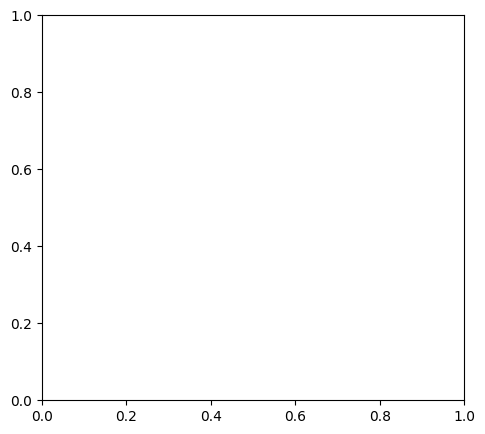

In [3]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(data['hive_temp'], kde=True)
plt.title('Distribution of Hive Temperature')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(data['hive_humidity'], kde=True)
plt.title('Distribution of Hive Humidity')

plt.tight_layout()
plt.show()

### Relationship Between Features and Target Variable

NameError: name 'data' is not defined

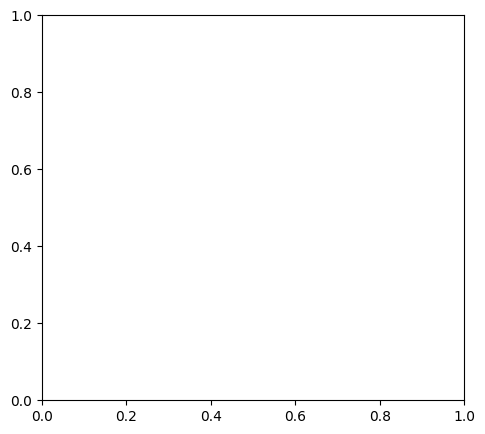

In [4]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='target', y='hive_temp', data=data)
plt.title('Hive Temperature vs. Queen Status')
plt.xlabel('Queen Present (0 = No, 1 = Yes)')
plt.ylabel('Hive Temperature')

plt.subplot(1, 2, 2)
sns.boxplot(x='target', y='hive_humidity', data=data)
plt.title('Hive Humidity vs. Queen Status')
plt.xlabel('Queen Present (0 = No, 1 = Yes)')
plt.ylabel('Hive Humidity')

plt.tight_layout()
plt.show()

### Time Series Analysis of Hive Temperature and Humidity

In [5]:
plt.figure(figsize=(15, 6))

plt.plot(data['timestamp'], data['hive_temp'], label='Hive Temperature')
plt.plot(data['timestamp'], data['hive_humidity'], label='Hive Humidity')
plt.title('Hive Temperature and Humidity Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'data' is not defined

<Figure size 1500x600 with 0 Axes>

In [ ]:
X = data[['hive_temp','hive_humidity','hive_pressure',
          'weather_temp','weather_humidity','wind_speed']]

y = data['target']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7058823529411765


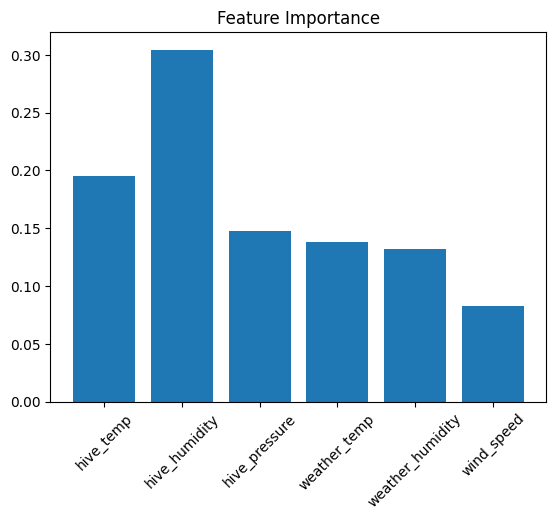

In [ ]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.bar(features, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [ ]:
sample = [[34, 70, 1012, 30, 60, 10]]  # example values
prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
def check_risk(temp, humidity):
    if temp > 38:
        return "High Temperature Risk"
    elif humidity < 40:
        return "Low Humidity Risk"
    else:
        return "Normal"

print(check_risk(39, 35))

High Temperature Risk


In [ ]:
manual_temp = float(input("Enter temperature: "))
manual_humidity = float(input("Enter humidity: "))

risk_status = check_risk(manual_temp, manual_humidity)
print(f"Risk status for temperature {manual_temp} and humidity {manual_humidity}: {risk_status}")

Enter temperature: 40
Enter humidity: 38
Risk status for temperature 40.0 and humidity 38.0: High Temperature Risk
